In [49]:
import wfdb

record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

ecg_signal = record.p_signal[:, 0]   # first channel
fs = record.fs                       # sampling frequency
print("Signal length:", len(ecg_signal), "| Sampling rate:", fs)

Signal length: 650000 | Sampling rate: 360


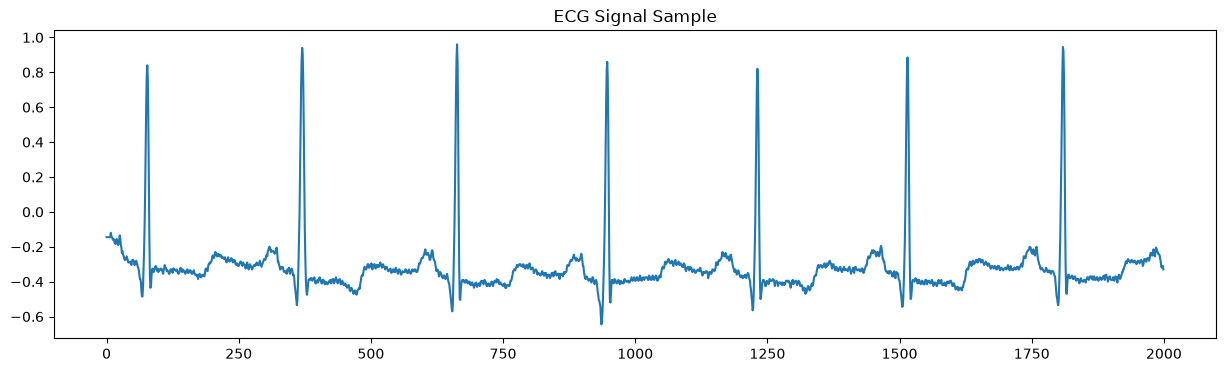

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))
plt.plot(ecg_signal[:2000])
plt.title("ECG Signal Sample")
plt.show()

In [32]:
import wfdb

# Try a handful of mitdb records
mitdb_records = ['100', '101', '200', '201', '203', '210', '219', '221']

for rec_name in mitdb_records:
    try:
        ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')
        rhythms_found = set(ann.aux_note) - {''}
        print(f"Record {rec_name}: {rhythms_found}")
    except Exception as e:
        print(f"Record {rec_name}: failed ({e})")

Record 100: {'(N\x00'}
Record 101: {'(N\x00'}
Record 200: {'(VT\x00', '(N\x00', '(B\x00'}
Record 201: {'(N', '(T\x00', '(N\x00', '(NOD\x00', '(AFIB\x00', '(SVTA'}
Record 203: {'(T\x00', '(AFL\x00', '(VT\x00', '(AFIB\x00'}
Record 210: {'(T\x00', '(VT\x00', '(AFIB\x00', '(B\x00'}
Record 219: {'(B\x00', '(T\x00', '(N\x00', 'MISSB\x00', '(AFIB\x00', 'PSE\x00'}
Record 221: {'(T\x00', '(VT\x00', '(AFIB\x00', '(B\x00'}


**Denoising**


In [17]:
from scipy.signal import butter, filtfilt, iirnotch

def denoise_ecg(ecg, fs):
    """
    Truth sheet ke exact numbers: 0.5-150 Hz bandpass + 50Hz notch
    """
    nyquist = fs / 2

    # Step 1: Bandpass filter (0.5 - 150 Hz)
    low = 0.5 / nyquist
    high = min(150 / nyquist, 0.99)   # fs kam hai to 150Hz nyquist se upar na chala jaye
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, ecg)

    # Step 2: 50Hz notch filter (powerline hum hatane ke liye)
    notch_freq = 50 / nyquist
    if notch_freq < 1.0:   # sirf tab lagao agar sampling rate ijazat de
        b_notch, a_notch = iirnotch(50, Q=30, fs=fs)
        filtered = filtfilt(b_notch, a_notch, filtered)

    return filtered

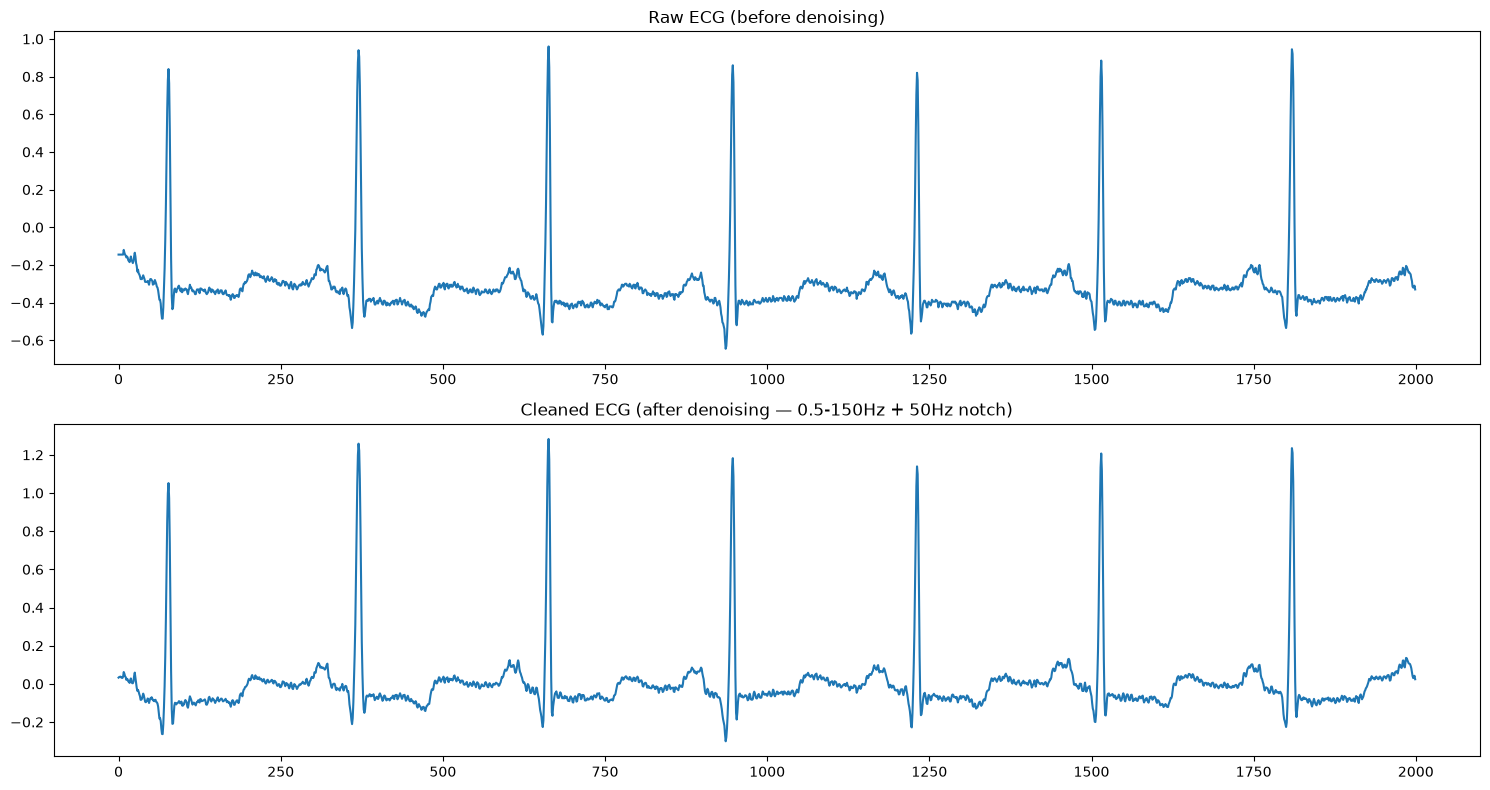

In [18]:
import matplotlib.pyplot as plt

raw_sample = ecg_signal[:2000]
cleaned_sample = denoise_ecg(raw_sample, fs)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(raw_sample)
axes[0].set_title("Raw ECG (before denoising)")
axes[1].plot(cleaned_sample)
axes[1].set_title("Cleaned ECG (after denoising — 0.5-150Hz + 50Hz notch)")
plt.tight_layout()
plt.show()

In [19]:
import wfdb
from collections import Counter

# MIT-BIH ke saare 48 record numbers
all_mitdb_records = [
    '100','101','102','103','104','105','106','107','108','109',
    '111','112','113','114','115','116','117','118','119','121',
    '122','123','124','200','201','202','203','205','207','208',
    '209','210','212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234'
]

record_rhythm_summary = {}

for rec_name in all_mitdb_records:
    try:
        ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')
        rhythms = [a.rstrip('\x00') for a, sym in zip(ann.aux_note, ann.symbol) if sym == '+']
        counts = Counter(rhythms)
        record_rhythm_summary[rec_name] = counts
    except Exception as e:
        print(f"Record {rec_name}: skip ({e})")

# Ab dekho konse records mein '(B' (brady) ya '(T' (tachy) hain
print("\n=== Records with Bradycardia ('(B') episodes ===")
for rec, counts in record_rhythm_summary.items():
    if '(B' in counts:
        print(f"Record {rec}: {counts['(B']} episodes")

print("\n=== Records with Tachycardia ('(T') episodes ===")
for rec, counts in record_rhythm_summary.items():
    if '(T' in counts:
        print(f"Record {rec}: {counts['(T']} episodes")


=== Records with Bradycardia ('(B') episodes ===
Record 106: 18 episodes
Record 119: 37 episodes
Record 200: 71 episodes
Record 207: 4 episodes
Record 210: 5 episodes
Record 213: 19 episodes
Record 217: 9 episodes
Record 219: 2 episodes
Record 221: 1 episodes
Record 223: 7 episodes
Record 228: 20 episodes
Record 233: 28 episodes

=== Records with Tachycardia ('(T') episodes ===
Record 106: 1 episodes
Record 119: 17 episodes
Record 124: 2 episodes
Record 201: 12 episodes
Record 203: 1 episodes
Record 208: 26 episodes
Record 210: 1 episodes
Record 214: 10 episodes
Record 219: 1 episodes
Record 221: 8 episodes
Record 223: 3 episodes
Record 233: 1 episodes


**Extraction of HRV Features**


In [28]:
import neurokit2 as nk
import numpy as np

def extract_hrv_features(rpeaks_times, fs):
    """
    rpeaks_times: R-peak ke timestamps (seconds mein), jo tumhare 
                   detect_rpeaks() function se aa rahe hain
    fs: sampling frequency
    Returns: dictionary of HRV features for ek recording
    """
    # R-peak times ko samples mein convert karo (neurokit ko samples chahiye)
    rpeaks_samples = (np.array(rpeaks_times) * fs).astype(int)
    
    # RR intervals nikalo (consecutive R-peaks ka difference, milliseconds mein)
    rr_intervals = np.diff(rpeaks_samples) / fs * 1000  # ms mein
    
    if len(rr_intervals) < 2:
        # Agar bohot kam beats hain to safe default return karo
        return {
            "mean_RR": np.nan, "SDNN": np.nan, "RMSSD": np.nan,
            "min_RR": np.nan, "max_RR": np.nan
        }
    
    mean_rr = np.mean(rr_intervals)
    sdnn = np.std(rr_intervals)  # variation kitna hai
    rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))  # irregularity (afib ke liye important)
    min_rr = np.min(rr_intervals)
    max_rr = np.max(rr_intervals)
    
    return {
        "mean_RR": mean_rr,
        "SDNN": sdnn,
        "RMSSD": rmssd,
        "min_RR": min_rr,
        "max_RR": max_rr
    }

In [29]:
import wfdb
import numpy as np
import neurokit2 as nk
from scipy.signal import butter, filtfilt, iirnotch
from collections import Counter

def denoise_ecg(ecg, fs):
    nyquist = fs / 2
    low = 0.5 / nyquist
    high = min(150 / nyquist, 0.99)
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, ecg)

    notch_freq = 50 / nyquist
    if notch_freq < 1.0:
        b_notch, a_notch = iirnotch(50, Q=30, fs=fs)
        filtered = filtfilt(b_notch, a_notch, filtered)

    return filtered

records = [
    '100', '101', '106', '119', '124', '200', '201', '203',
    '207', '208', '210', '213', '214', '219', '221',
    '223', '228', '233'
]   # 217 (paced beats) hata diya

target_map = {
    '(N': 'normal',
    '(B': 'brady',
    '(T': 'tachy',
    '(AFIB': 'afib'
}

window_sec = 5
all_features = []
all_labels = []

for rec_name in records:
    try:
        record = wfdb.rdrecord(rec_name, pn_dir='mitdb')
        ann = wfdb.rdann(rec_name, 'atr', pn_dir='mitdb')
    except Exception as e:
        print(f"Record {rec_name}: skip ({e})")
        continue

    ecg = record.p_signal[:, 0]
    fs = record.fs

    rhythm_points = [(s, a.rstrip('\x00')) for s, a, sym in zip(ann.sample, ann.aux_note, ann.symbol) if sym == '+']
    if not rhythm_points:
        continue
    rhythm_points.append((len(ecg), None))

    for i in range(len(rhythm_points) - 1):
        start_sample, rhythm_label = rhythm_points[i]
        end_sample, _ = rhythm_points[i + 1]

        clean_label = target_map.get(rhythm_label)
        if clean_label is None:
            continue

        window_samples = int(window_sec * fs)
        for w_start in range(start_sample, end_sample - window_samples, window_samples):
            w_end = w_start + window_samples
            segment = ecg[w_start:w_end]
            try:
                cleaned_segment = denoise_ecg(segment, fs)
                signals, info = nk.ecg_process(cleaned_segment, sampling_rate=fs)
                r_peaks = info['ECG_R_Peaks']
                if len(r_peaks) < 5:
                    continue
                rr_intervals = np.diff(r_peaks) / fs
                avg_hr = 60 / np.mean(rr_intervals)
                rr_std = np.std(rr_intervals)
                rr_min = np.min(rr_intervals)
                rr_max = np.max(rr_intervals)
                rr_range = rr_max - rr_min

                # ---- NAYA: RMSSD (irregularity ka best measure — afib ke liye critical) ----
                rmssd = np.sqrt(np.mean(np.diff(rr_intervals) ** 2))

                all_features.append([avg_hr, rr_std, rr_min, rr_max, rr_range, rmssd])
                all_labels.append(clean_label)
            except Exception:
                continue

print("Total samples collected:", len(all_features))
print("Label counts:", Counter(all_labels))

c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neurokit2\signal\signal_period.py:83: NeuroKitWarning: Too few peaks detected to compute the rate. Returning empty vector.
  warn(
c:\Users\DELL\Desktop\Cardio_Core\venv\Lib\site-packages\neu

Total samples collected: 5150
Label counts: Counter({'normal': 3333, 'afib': 1364, 'brady': 325, 'tachy': 128})


In [33]:
def detect_rpeaks(ecg, fs):
    cleaned = denoise_ecg(ecg, fs)
    signals, info = nk.ecg_process(cleaned, sampling_rate=fs)
    r_peak_samples = info['ECG_R_Peaks']
    times = [i / fs for i in r_peak_samples]
    return times

In [34]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np

X = np.array(all_features)
y = np.array(all_labels)

# Sabhi models ke liye same custom class weights (jo humne pehle decide kiye the)
class_weights = {
    'normal': 1,
    'afib': 1,
    'brady': 3,
    'tachy': 5
}

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight=class_weights),
    "SVM": SVC(class_weight=class_weights),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)   # KNN class_weight support nahi karta, isliye chhoda
}

print("=== Model Comparison (5-fold Cross-Validation Accuracy) ===\n")
results = {}

for name, model in models.items():
    data_to_use = X if name == "Random Forest" else X_scaled   # RF ko scaling ki zaroorat nahi
    scores = cross_val_score(model, data_to_use, y, cv=5)
    results[name] = scores.mean()
    print(f"{name}: {scores.mean():.3f} (+/- {scores.std():.3f})")

print("\n=== Best Model ===")
best_model_name = max(results, key=results.get)
print(f"{best_model_name} with average accuracy: {results[best_model_name]:.3f}")

=== Model Comparison (5-fold Cross-Validation Accuracy) ===

Random Forest: 0.661 (+/- 0.103)
Logistic Regression: 0.590 (+/- 0.083)
SVM: 0.654 (+/- 0.094)
K-Nearest Neighbors: 0.686 (+/- 0.088)

=== Best Model ===
K-Nearest Neighbors with average accuracy: 0.686


In [35]:
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weights)
rf.fit(X_train, y_train)
print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test)))

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("=== K-Nearest Neighbors ===")
print(classification_report(y_test, knn.predict(X_test_scaled)))

=== Random Forest ===
              precision    recall  f1-score   support

        afib       0.67      0.68      0.68       341
       brady       0.76      0.64      0.70        81
      normal       0.85      0.86      0.85       834
       tachy       0.38      0.44      0.41        32

    accuracy                           0.79      1288
   macro avg       0.67      0.65      0.66      1288
weighted avg       0.79      0.79      0.79      1288

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

        afib       0.69      0.74      0.71       341
       brady       0.77      0.69      0.73        81
      normal       0.88      0.87      0.88       834
       tachy       0.61      0.44      0.51        32

    accuracy                           0.81      1288
   macro avg       0.74      0.68      0.71      1288
weighted avg       0.81      0.81      0.81      1288



=== Final Classification Report ===
              precision    recall  f1-score   support

        afib       0.66      0.66      0.66       341
       brady       0.60      0.63      0.61        81
      normal       0.85      0.85      0.85       834
       tachy       0.45      0.44      0.44        32

    accuracy                           0.77      1288
   macro avg       0.64      0.64      0.64      1288
weighted avg       0.77      0.77      0.77      1288



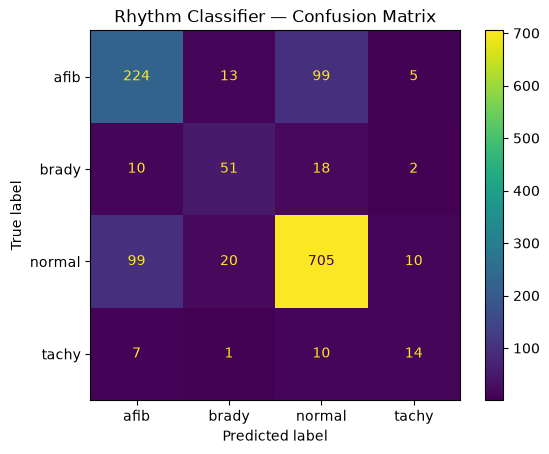

In [26]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Agar Random Forest jeeta (zyada chance hai is data ke liye):
rhythm_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight=class_weights
)
rhythm_model.fit(X_train, y_train)

y_pred = rhythm_model.predict(X_test)

print("=== Final Classification Report ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Rhythm Classifier — Confusion Matrix")
plt.show()


def classify_rhythm(feat):
    feat = np.array(feat).reshape(1, -1)
    pred = rhythm_model.predict(feat)[0]
    conf = rhythm_model.predict_proba(feat).max()
    return pred, conf

In [50]:
import joblib
joblib.dump(rhythm_model, 'rhythm_model.pkl')
print("Model saved!")

Model saved!


In [36]:
import zipfile
import os

zip_path = r"C:\Users\DELL\Downloads\the-circor-digiscope-phonocardiogram-dataset-1.0.3.zip"
extract_to = r"C:\Users\DELL\Downloads\heart_sounds_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extracted!")
print(os.listdir(extract_to))

Extracted!
['the-circor-digiscope-phonocardiogram-dataset-1.0.3']


In [37]:
import glob

wav_files = glob.glob(extract_to + r"\**\*.wav", recursive=True)
print("Total wav files found:", len(wav_files))
print("Sample file:", wav_files[0])

Total wav files found: 3163
Sample file: C:\Users\DELL\Downloads\heart_sounds_data\the-circor-digiscope-phonocardiogram-dataset-1.0.3\training_data\13918_AV.wav


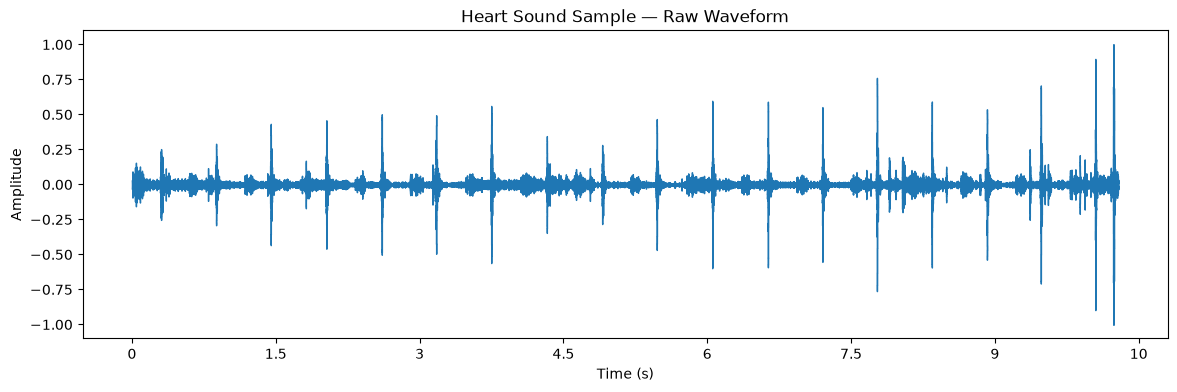

Sampling rate: 4000
Duration (seconds): 10.288


In [38]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

y, sr = librosa.load(wav_files[0], sr=None)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Heart Sound Sample — Raw Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

print("Sampling rate:", sr)
print("Duration (seconds):", len(y)/sr)

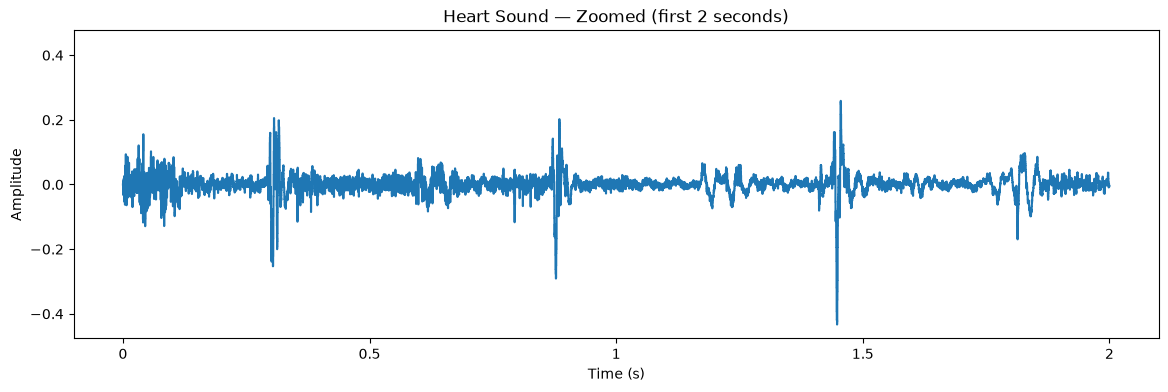

In [39]:
import numpy as np

# Sirf pehle 2 second ka data lo
duration_to_plot = 2  # seconds
samples_to_plot = int(duration_to_plot * sr)

plt.figure(figsize=(14, 4))
librosa.display.waveshow(y[:samples_to_plot], sr=sr)
plt.title("Heart Sound — Zoomed (first 2 seconds)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

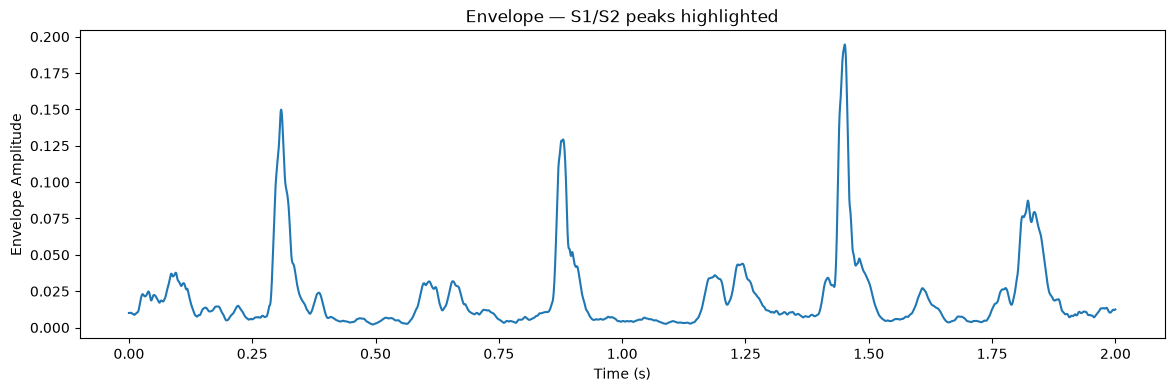

In [40]:
from scipy.signal import butter, filtfilt, hilbert

def get_envelope(signal, sr, low_freq=25, high_freq=200):
    nyquist = sr / 2
    low = low_freq / nyquist
    high = min(high_freq / nyquist, 0.99)
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)

    # Envelope nikalo (Hilbert transform se) — ye peaks ko smooth karke highlight karta hai
    analytic_signal = hilbert(filtered)
    envelope = np.abs(analytic_signal)

    # Thoda smooth karo taake chhoti noise spikes na aayein
    from scipy.ndimage import uniform_filter1d
    envelope_smooth = uniform_filter1d(envelope, size=int(0.02 * sr))  # 20ms window

    return filtered, envelope_smooth

filtered_signal, envelope = get_envelope(y, sr)

# Plot karke dekho envelope kaisa dikh raha hai (pehle 2 second)
plt.figure(figsize=(14, 4))
plt.plot(np.arange(samples_to_plot)/sr, envelope[:samples_to_plot])
plt.title("Envelope — S1/S2 peaks highlighted")
plt.xlabel("Time (s)")
plt.ylabel("Envelope Amplitude")
plt.show()

In [42]:
from scipy.signal import find_peaks

min_distance = int(0.08 * sr)  # ~80ms, taake bohot close peaks merge na hon

# prominence = peak apne surrounding baseline se kitna "uبhrا" hua hai
# height ki jagah prominence better hai kyunke S1/S2 ka amplitude vary karta hai
peaks, properties = find_peaks(envelope, distance=min_distance, prominence=0.01)

peak_times = peaks / sr
print("Total peaks found:", len(peaks))
print(peak_times)

Total peaks found: 50
[ 0.095    0.3085   0.65675  0.88025  1.244    1.45125  1.60875  1.8225
  2.031    2.4085   2.609    2.959    3.1765   3.53225  3.7495   3.983
  4.1115   4.33225  4.6385   4.90975  5.21575  5.478    5.84     5.969
  6.05825  6.189    6.41375  6.637    6.9855   7.2055   7.55775  7.77425
  7.90075  8.042    8.131    8.24625  8.3465   8.49625  8.6975   8.84125
  8.9215   9.26875  9.36675  9.483    9.702    9.8355   9.94075 10.04825
 10.13725 10.23875]


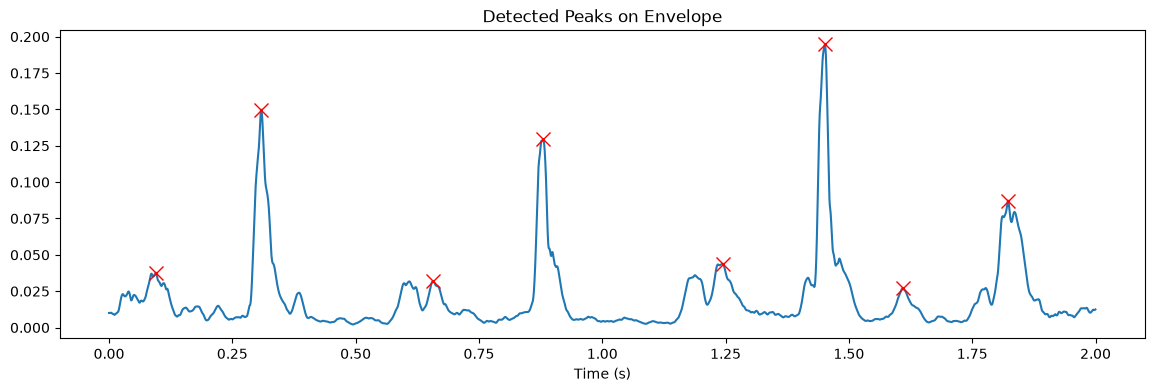

In [43]:
plt.figure(figsize=(14, 4))
plt.plot(np.arange(samples_to_plot)/sr, envelope[:samples_to_plot])
plt.plot(peak_times[peak_times < 2], envelope[peaks[peak_times < 2]], "rx", markersize=10)
plt.title("Detected Peaks on Envelope")
plt.xlabel("Time (s)")
plt.show()

In [44]:
# Peak times already mil chuke hain (peaks aur peak_times variables se)
peak_times_2s = peak_times[peak_times < 2]  # sirf pehle 2 second ke peaks

print("Total peaks:", len(peak_times_2s))
print("\nPeak times (seconds):")
for i, t in enumerate(peak_times_2s):
    print(f"  Peak {i+1}: {t:.3f}s")

# Ab consecutive peaks ke beech gaps nikalo
gaps = np.diff(peak_times_2s)

print("\nGaps between consecutive peaks:")
for i, g in enumerate(gaps):
    print(f"  Gap {i+1} (Peak{i+1}->Peak{i+2}): {g:.3f}s")

print(f"\nMedian gap: {np.median(gaps):.3f}s")
print(f"Min gap: {np.min(gaps):.3f}s, Max gap: {np.max(gaps):.3f}s")

Total peaks: 8

Peak times (seconds):
  Peak 1: 0.095s
  Peak 2: 0.308s
  Peak 3: 0.657s
  Peak 4: 0.880s
  Peak 5: 1.244s
  Peak 6: 1.451s
  Peak 7: 1.609s
  Peak 8: 1.823s

Gaps between consecutive peaks:
  Gap 1 (Peak1->Peak2): 0.213s
  Gap 2 (Peak2->Peak3): 0.348s
  Gap 3 (Peak3->Peak4): 0.224s
  Gap 4 (Peak4->Peak5): 0.364s
  Gap 5 (Peak5->Peak6): 0.207s
  Gap 6 (Peak6->Peak7): 0.157s
  Gap 7 (Peak7->Peak8): 0.214s

Median gap: 0.214s
Min gap: 0.157s, Max gap: 0.364s


In [45]:
def label_s1_s2(peak_times, gaps):
    """
    Har peak ko S1 ya S2 label karta hai, gaps ko median se compare karke.
    Assumption: pehla peak S1 hai (adjust karna pad sakta hai agar galat nikle).
    """
    labels = ['S1']  # pehla peak S1 se start karte hain
    median_gap = np.median(gaps)
    
    for i, gap in enumerate(gaps):
        prev_label = labels[-1]
        if gap < median_gap:
            # chhota gap = systole = S1 ke baad S2 aata hai
            next_label = 'S2' if prev_label == 'S1' else 'S1'
        else:
            # bada gap = diastole = S2 ke baad S1 aata hai
            next_label = 'S1' if prev_label == 'S2' else 'S2'
        labels.append(next_label)
    
    return labels

labels = label_s1_s2(peak_times_2s, gaps)
for t, l in zip(peak_times_2s, labels):
    print(f"{t:.3f}s -> {l}")

0.095s -> S1
0.308s -> S2
0.657s -> S1
0.880s -> S2
1.244s -> S1
1.451s -> S2
1.609s -> S1
1.823s -> S2


In [46]:
def label_s1_s2(peak_times, gaps):
    median_gap = np.median(gaps)
    labels = ['S1']  # assumption: pehla peak S1 hai
    warnings = []

    for i, gap in enumerate(gaps):
        prev_label = labels[-1]
        expected_next = 'S2' if prev_label == 'S1' else 'S1'

        # Check: S1 ke baad S2 ka gap chhota (systole) hona chahiye
        if prev_label == 'S1' and gap >= median_gap:
            warnings.append(
                f"⚠️ Peak {i+1}->{i+2} ({peak_times[i]:.3f}s->{peak_times[i+1]:.3f}s): "
                f"expected SHORT gap (systole) but got {gap:.3f}s -- possible missed/extra peak"
            )
        # Check: S2 ke baad S1 ka gap bada (diastole) hona chahiye
        if prev_label == 'S2' and gap < median_gap:
            warnings.append(
                f"⚠️ Peak {i+1}->{i+2} ({peak_times[i]:.3f}s->{peak_times[i+1]:.3f}s): "
                f"expected LONG gap (diastole) but got {gap:.3f}s -- possible missed/extra peak"
            )

        labels.append(expected_next)

    return labels, warnings

labels, warnings = label_s1_s2(peak_times_2s, gaps)

print("Labels:")
for t, l in zip(peak_times_2s, labels):
    print(f"  {t:.3f}s -> {l}")

print("\nWarnings:")
if warnings:
    for w in warnings:
        print(" ", w)
else:
    print("  Koi anomaly nahi mili — pattern clean hai!")
    

Labels:
  0.095s -> S1
  0.308s -> S2
  0.657s -> S1
  0.880s -> S2
  1.244s -> S1
  1.451s -> S2
  1.609s -> S1
  1.823s -> S2

Warnings:
  ⚠️ Peak 3->4 (0.657s->0.880s): expected SHORT gap (systole) but got 0.224s -- possible missed/extra peak
  ⚠️ Peak 6->7 (1.451s->1.609s): expected LONG gap (diastole) but got 0.157s -- possible missed/extra peak
  ⚠️ Peak 7->8 (1.609s->1.823s): expected SHORT gap (systole) but got 0.214s -- possible missed/extra peak


Total peaks (2s): 8
Peak times: [0.095 0.308 0.657 0.88  1.244 1.451 1.609 1.822]
Amplitudes: [0.0377 0.1498 0.0318 0.1293 0.0439 0.1946 0.0271 0.0873]

Gaps: [0.214 0.348 0.224 0.364 0.207 0.157 0.214]
Threshold: 0.286

Labels:
  0.095s -> S1
  0.308s -> S2
  0.657s -> S1
  0.880s -> S2
  1.244s -> S1
  1.451s -> S2
  1.609s -> S1
  1.823s -> S2

Warnings:
  Peak6->7 (1.451s->1.609s): expected LONG gap, got 0.157s


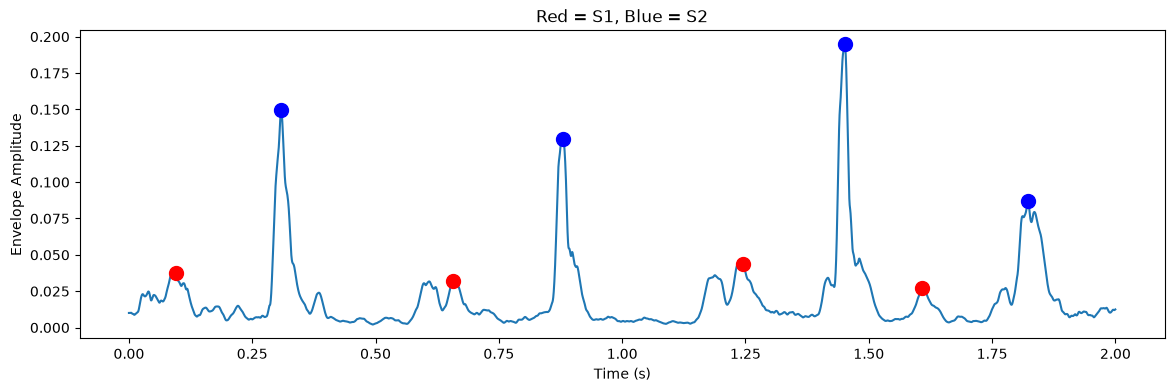

In [47]:
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy.ndimage import uniform_filter1d
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Envelope banao ----------
def get_envelope(signal, sr, low_freq=25, high_freq=200):
    nyquist = sr / 2
    low = low_freq / nyquist
    high = min(high_freq / nyquist, 0.99)
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)
    analytic_signal = hilbert(filtered)
    envelope = np.abs(analytic_signal)
    envelope_smooth = uniform_filter1d(envelope, size=int(0.02 * sr))
    return filtered, envelope_smooth

filtered_signal, envelope = get_envelope(y, sr)

# ---------- 2) Peaks nikalo ----------
peaks, properties = find_peaks(envelope, distance=int(0.08*sr), prominence=0.015)
peak_times = peaks / sr

# sirf pehle 2 second ke peaks (testing ke liye)
mask = peak_times < 2
peak_times_2s = peak_times[mask]
peaks_2s = peaks[mask]

print("Total peaks (2s):", len(peak_times_2s))
print("Peak times:", np.round(peak_times_2s, 3))
print("Amplitudes:", np.round(envelope[peaks_2s], 4))

# ---------- 3) Gaps aur threshold (clustering-based) ----------
gaps = np.diff(peak_times_2s)
print("\nGaps:", np.round(gaps, 3))

sorted_gaps = np.sort(gaps)
diffs = np.diff(sorted_gaps)
split_idx = np.argmax(diffs)
threshold = (sorted_gaps[split_idx] + sorted_gaps[split_idx + 1]) / 2
print("Threshold:", round(threshold, 3))

# ---------- 4) S1/S2 labeling (warnings ke sath) ----------
def label_s1_s2(peak_times, gaps, threshold):
    labels = ['S1']
    warnings = []
    for i, gap in enumerate(gaps):
        prev_label = labels[-1]
        expected_next = 'S2' if prev_label == 'S1' else 'S1'
        if prev_label == 'S1' and gap >= threshold:
            warnings.append(f"Peak{i+1}->{i+2} ({peak_times[i]:.3f}s->{peak_times[i+1]:.3f}s): expected SHORT gap, got {gap:.3f}s")
        if prev_label == 'S2' and gap < threshold:
            warnings.append(f"Peak{i+1}->{i+2} ({peak_times[i]:.3f}s->{peak_times[i+1]:.3f}s): expected LONG gap, got {gap:.3f}s")
        labels.append(expected_next)
    return labels, warnings

labels, warnings = label_s1_s2(peak_times_2s, gaps, threshold)

print("\nLabels:")
for t, l in zip(peak_times_2s, labels):
    print(f"  {t:.3f}s -> {l}")

print("\nWarnings:")
if warnings:
    for w in warnings:
        print(" ", w)
else:
    print("  Koi anomaly nahi — clean pattern!")

# ---------- 5) Plot (visual verify) ----------
plt.figure(figsize=(14, 4))
plt.plot(np.arange(len(envelope[:int(2*sr)]))/sr, envelope[:int(2*sr)])
for t, l in zip(peak_times_2s, labels):
    color = 'red' if l == 'S1' else 'blue'
    plt.scatter(t, envelope[int(t*sr)], c=color, s=100, zorder=5)
plt.title("Red = S1, Blue = S2")
plt.xlabel("Time (s)")
plt.ylabel("Envelope Amplitude")
plt.show()

In [48]:
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy.ndimage import uniform_filter1d
import numpy as np

def segment_s1s2(pcg, fs):
    """
    PCG signal se S1 aur S2 heart sound peaks segment karta hai.
    
    Args:
        pcg: raw heart sound signal (1D numpy array)
        fs: sampling rate (Hz)
    
    Returns:
        s1_times: S1 sounds ke timestamps (seconds, numpy array)
        s2_times: S2 sounds ke timestamps (seconds, numpy array)
    """
    # 1) Envelope banao (bandpass filter + Hilbert transform + smoothing)
    nyquist = fs / 2
    low = 25 / nyquist
    high = min(200 / nyquist, 0.99)
    b, a = butter(4, [low, high], btype='band')
    filtered = filtfilt(b, a, pcg)
    envelope = np.abs(hilbert(filtered))
    envelope = uniform_filter1d(envelope, size=int(0.02 * fs))

    # 2) Peaks dhoondo
    peaks, _ = find_peaks(envelope, distance=int(0.08*fs), prominence=0.015)
    peak_times = peaks / fs

    if len(peak_times) < 2:
        return np.array([]), np.array([])

    # 3) Gaps ka threshold nikalo (clustering-based: short=systole, long=diastole)
    gaps = np.diff(peak_times)
    if len(gaps) >= 2:
        sorted_gaps = np.sort(gaps)
        diffs = np.diff(sorted_gaps)
        split_idx = np.argmax(diffs)
        threshold = (sorted_gaps[split_idx] + sorted_gaps[split_idx + 1]) / 2
    else:
        threshold = np.median(gaps)

    # 4) Amplitude se decide karo pehla peak S1 hai ya S2
    #    (S1 generally lower amplitude hota hai S2 se — humari testing me confirm hua)
    amps = envelope[peaks]
    labels = ['S1'] if amps[0] < amps[1] else ['S2']

    for i in range(len(gaps)):
        prev_label = labels[-1]
        next_label = 'S2' if prev_label == 'S1' else 'S1'
        labels.append(next_label)

    # 5) S1/S2 times alag karo
    s1_times = np.array([t for t, l in zip(peak_times, labels) if l == 'S1'])
    s2_times = np.array([t for t, l in zip(peak_times, labels) if l == 'S2'])

    return s1_times, s2_times


# ---------- Test karne ke liye (apni y, sr variables se) ----------
s1_times, s2_times = segment_s1s2(y, sr)
print("S1 times:", np.round(s1_times[:10], 3))
print("S2 times:", np.round(s2_times[:10], 3))
print(f"\nTotal S1: {len(s1_times)}, Total S2: {len(s2_times)}")

S1 times: [0.095 0.657 1.244 1.609 2.031 2.609 3.176 3.75  4.332 4.91 ]
S2 times: [0.308 0.88  1.451 1.822 2.408 2.959 3.532 4.112 4.638 5.216]

Total S1: 24, Total S2: 24


In [51]:
import glob

csv_files = glob.glob(extract_to + r"\**\*.csv", recursive=True)
print("CSV files found:", csv_files)

CSV files found: ['C:\\Users\\DELL\\Downloads\\heart_sounds_data\\the-circor-digiscope-phonocardiogram-dataset-1.0.3\\training_data.csv']


In [52]:
import pandas as pd

labels_df = pd.read_csv(r'C:\Users\DELL\Downloads\heart_sounds_data\the-circor-digiscope-phonocardiogram-dataset-1.0.3\training_data.csv')

print("Columns:", labels_df.columns.tolist())
print("\nFirst 10 rows:")
print(labels_df.head(10))
print("\nShape:", labels_df.shape)

Columns: ['Patient ID', 'Recording locations:', 'Age', 'Sex', 'Height', 'Weight', 'Pregnancy status', 'Murmur', 'Murmur locations', 'Most audible location', 'Systolic murmur timing', 'Systolic murmur shape', 'Systolic murmur grading', 'Systolic murmur pitch', 'Systolic murmur quality', 'Diastolic murmur timing', 'Diastolic murmur shape', 'Diastolic murmur grading', 'Diastolic murmur pitch', 'Diastolic murmur quality', 'Outcome', 'Campaign', 'Additional ID']

First 10 rows:
   Patient ID Recording locations:    Age     Sex  Height  Weight  \
0        2530          AV+PV+TV+MV  Child  Female    98.0   15.90   
1        9979          AV+PV+TV+MV  Child  Female   103.0   13.10   
2        9983          AV+PV+TV+MV  Child    Male   115.0   19.10   
3       13918          AV+PV+TV+MV  Child    Male    98.0   15.90   
4       14241          AV+PV+TV+MV  Child    Male    87.0   11.20   
5       14998          AV+PV+TV+MV  Child    Male     NaN     NaN   
6       23625          AV+PV+TV+MV  Chi

In [53]:
import os

def get_patient_id(wav_path):
    filename = os.path.basename(wav_path)
    return filename.split('_')[0]

# Patient ID -> Murmur label mapping
patient_murmur_map = dict(zip(labels_df['Patient ID'].astype(str), labels_df['Murmur']))

print("Total patients in CSV:", len(patient_murmur_map))
print("Sample mapping:", list(patient_murmur_map.items())[:5])

Total patients in CSV: 942
Sample mapping: [('2530', 'Absent'), ('9979', 'Present'), ('9983', 'Unknown'), ('13918', 'Present'), ('14241', 'Present')]


In [54]:
import numpy as np
import librosa

def extract_murmur_features(wav_path):
    try:
        y_wav, sr_wav = librosa.load(wav_path, sr=None)
    except Exception:
        return None

    s1_times, s2_times = segment_s1s2(y_wav, sr_wav)

    if len(s1_times) < 2 or len(s2_times) < 2:
        return None

    s1_samples = (s1_times * sr_wav).astype(int)
    s2_samples = (s2_times * sr_wav).astype(int)

    systolic_energies = []
    diastolic_energies = []

    for i in range(min(len(s1_samples), len(s2_samples))):
        s1, s2 = s1_samples[i], s2_samples[i]
        if s1 < s2 <= len(y_wav):
            window = y_wav[s1:s2]
            if len(window) > 0:
                systolic_energies.append(np.mean(window**2))
        if i + 1 < len(s1_samples):
            next_s1 = s1_samples[i+1]
            if s2 < next_s1 <= len(y_wav):
                window = y_wav[s2:next_s1]
                if len(window) > 0:
                    diastolic_energies.append(np.mean(window**2))

    if not systolic_energies and not diastolic_energies:
        return None

    avg_systolic = np.mean(systolic_energies) if systolic_energies else 0
    avg_diastolic = np.mean(diastolic_energies) if diastolic_energies else 0
    std_systolic = np.std(systolic_energies) if len(systolic_energies) > 1 else 0
    std_diastolic = np.std(diastolic_energies) if len(diastolic_energies) > 1 else 0
    zcr = np.mean(librosa.feature.zero_crossing_rate(y_wav)[0])
    spec_centroid = np.mean(librosa.feature.spectral_centroid(y=y_wav, sr=sr_wav)[0])

    return [avg_systolic, avg_diastolic, std_systolic, std_diastolic, zcr, spec_centroid]

In [55]:
from collections import Counter
import time

all_murmur_features = []
all_murmur_labels = []

start_time = time.time()
skipped_unknown = 0
skipped_no_peaks = 0

for idx, wav_path in enumerate(wav_files):
    pid = get_patient_id(wav_path)
    label = patient_murmur_map.get(pid)

    if label not in ['Present', 'Absent']:
        skipped_unknown += 1
        continue

    feat = extract_murmur_features(wav_path)
    if feat is None:
        skipped_no_peaks += 1
        continue

    all_murmur_features.append(feat)
    all_murmur_labels.append(label)

    # Progress dikhane ke liye har 200 files ke baad update
    if (idx + 1) % 200 == 0:
        elapsed = time.time() - start_time
        print(f"Processed {idx+1}/{len(wav_files)} files... ({elapsed:.1f}s elapsed)")

print(f"\nDone! Total time: {time.time() - start_time:.1f}s")
print("Total usable samples:", len(all_murmur_features))
print("Label counts:", Counter(all_murmur_labels))
print("Skipped (Unknown label):", skipped_unknown)
print("Skipped (no S1/S2 peaks found):", skipped_no_peaks)

Processed 200/3163 files... (9.5s elapsed)
Processed 400/3163 files... (15.9s elapsed)
Processed 600/3163 files... (22.6s elapsed)
Processed 800/3163 files... (29.3s elapsed)
Processed 1000/3163 files... (36.2s elapsed)
Processed 1200/3163 files... (43.6s elapsed)
Processed 1400/3163 files... (50.0s elapsed)
Processed 1600/3163 files... (54.4s elapsed)
Processed 1800/3163 files... (59.0s elapsed)
Processed 2000/3163 files... (63.9s elapsed)
Processed 2200/3163 files... (68.7s elapsed)
Processed 2400/3163 files... (73.7s elapsed)
Processed 2600/3163 files... (78.7s elapsed)
Processed 2800/3163 files... (84.1s elapsed)
Processed 3000/3163 files... (90.0s elapsed)

Done! Total time: 94.9s
Total usable samples: 3007
Label counts: Counter({'Absent': 2391, 'Present': 616})
Skipped (Unknown label): 156
Skipped (no S1/S2 peaks found): 0


=== Murmur Classifier Results ===
              precision    recall  f1-score   support

      Absent       0.83      0.89      0.86       598
     Present       0.41      0.29      0.34       154

    accuracy                           0.77       752
   macro avg       0.62      0.59      0.60       752
weighted avg       0.74      0.77      0.75       752



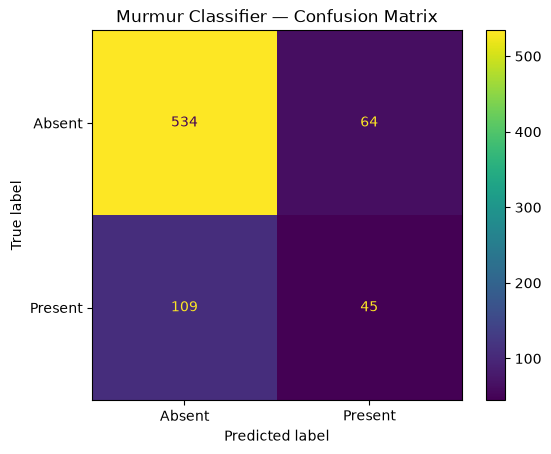

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_murmur = np.array(all_murmur_features)
y_murmur = np.array(all_murmur_labels)

X_train, X_test, y_train, y_test = train_test_split(
    X_murmur, y_murmur, test_size=0.25, random_state=42, stratify=y_murmur
)

murmur_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
murmur_model.fit(X_train, y_train)

y_pred = murmur_model.predict(X_test)

print("=== Murmur Classifier Results ===")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Murmur Classifier — Confusion Matrix")
plt.savefig('murmur_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [57]:
!pip install imbalanced-learn --quiet


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Before SMOTE: Counter({np.str_('Absent'): 1793, np.str_('Present'): 462})
After SMOTE: Counter({np.str_('Absent'): 1793, np.str_('Present'): 1793})

=== Murmur Classifier (with SMOTE) Results ===
              precision    recall  f1-score   support

      Absent       0.84      0.81      0.82       598
     Present       0.35      0.40      0.37       154

    accuracy                           0.72       752
   macro avg       0.59      0.60      0.60       752
weighted avg       0.74      0.72      0.73       752



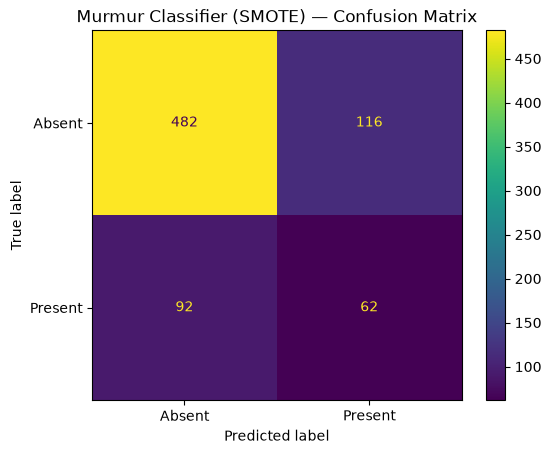

In [60]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Pehle jaisa hi train/test split (SMOTE sirf training data pe lagana hai, test pe nahi!)
X_train, X_test, y_train, y_test = train_test_split(
    X_murmur, y_murmur, test_size=0.25, random_state=42, stratify=y_murmur
)

print("Before SMOTE:", Counter(y_train))

# SMOTE sirf training set pe apply karo
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_smote))

# Naya model train karo balanced data pe
murmur_model_smote = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
murmur_model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = murmur_model_smote.predict(X_test)

print("\n=== Murmur Classifier (with SMOTE) Results ===")
print(classification_report(y_test, y_pred_smote))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_smote)
plt.title("Murmur Classifier (SMOTE) — Confusion Matrix")
plt.savefig('murmur_confusion_matrix_smote.png', dpi=150, bbox_inches='tight')
plt.show()

In [61]:
import joblib
joblib.dump(murmur_model_smote, 'murmur_model.pkl')
print("Saved!")

Saved!
